In [ ]:
#The start of the project is to gather data from the ENTSOE API and the Open Meteo API, and then merge them into a single DataFrame for analysis. The code below accomplishes this task.

from entsoe import EntsoePandasClient
import pandas as pd
import matplotlib.pyplot as plt
import openmeteo_requests
import requests_cache
from retry_requests import retry

################--WEATHER--#######################################
cache_session=requests_cache.CachedSession(".cache",expire_after=3600)
retry_session=retry(cache_session,retries=5,backoff_factor=0.2)
om=openmeteo_requests.Client(session=retry_session)

params={
    "latitude":37.9838,
    "longitude":23.7275,
    "start_date":"2023-01-01",
    "end_date":"2026-08-06",
    "hourly":["temperature_2m"],
    "timezone":"Europe/Athens"
}

response=om.weather_api("https://archive-api.open-meteo.com/v1/archive",params=params)[0]
hourly=response.Hourly()
temps=hourly.Variables(0).ValuesAsNumpy()
times=pd.date_range(
    start=pd.to_datetime(hourly.Time(),unit="s",utc=True),
    end=pd.to_datetime(hourly.TimeEnd(),unit="s",utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left"

)

weather=pd.DataFrame({"time":times,"temp_athens":temps})
weather.set_index("time",inplace=True)
weather.index=weather.index.tz_convert("Europe/Athens")
######################--WEATHER--####################################

#print(f"Weather data shape: {weather.shape}")
#print(weather.head(48))


client = EntsoePandasClient(api_key='cd2067be-0cdf-433d-8712-faefd8955a70')

start = pd.Timestamp('2023-01-01', tz='Europe/Athens')
end = pd.Timestamp('2027-01-01', tz='Europe/Athens')

load = client.query_load('GR', start=start, end=end)
load_hourly=load.resample("h").mean()
load_by_month=load.groupby(load.index.month).agg(["mean","max","min"])
highest_month=load.groupby(load.index.month).mean().idxmax()
lowest_month=load.groupby(load.index.month).mean().idxmin()


#The code below is for data exploration and visualization. It provides a summary of the load and weather data, including their shapes, descriptive statistics, and any missing values. Additionally, it visualizes the relationship between temperature and electricity load using a scatter plot.

#print(f"Load Hourly Shape: {load_hourly.shape}")
#print(f"Weather Shape: {weather.shape}")
#print("\nData summary:")
#print(load.describe())
#print(f"\nDate range: {load.index[0]} to {load.index[-1]}")
#print(f"Any missing values?:{load.isna().sum()}")
#print("Load Statistics By Month:")
#print(load_by_month)
#print(f"\nMonth With The Highest Average Load: {highest_month}")
#print(f"\nMonth With the Lowesr Average Load: {lowest_month}")

#plt.figure(figsize=(14,6))
#load.plot(title="Greek Electricity Demand 2023-2026",
          #ylabel="Load (MW)",
          #xlabel="Date"
          #)
#plt.grid(True)
#plt.show()

data=pd.concat([load_hourly,weather],axis=1)
data=data.dropna()

print(f"Merged Data Shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
print("\nFirst 48 Hours:")
print(data.head(48))

print("\nData Summary:")
print(data.describe())

print(f"\nAny Missing Values?")
print(data.isna().sum())

#Quick Graphical Exploration of the Relationship Between Temperature and Electricity Load

plt.figure(figsize=(12, 6))
plt.scatter(data['temp_athens'], data['Actual Load'], alpha=0.3, s=1)
plt.xlabel('Temperature (°C)')
plt.ylabel('Load (MW)')
plt.title('Greek Electricity Load vs Temperature')
plt.grid(True)
plt.show()


KeyboardInterrupt: 

                           temp_athens  Hour  Day Of The Week  Month  Weekend
2023-01-01 00:00:00+02:00     7.700000     0                6      1     True
2023-01-01 01:00:00+02:00     7.150000     1                6      1     True
2023-01-01 02:00:00+02:00     6.200000     2                6      1     True
2023-01-01 03:00:00+02:00     6.450000     3                6      1     True
2023-01-01 04:00:00+02:00     6.050000     4                6      1     True
2023-01-01 05:00:00+02:00     6.250000     5                6      1     True
2023-01-01 06:00:00+02:00     6.050000     6                6      1     True
2023-01-01 07:00:00+02:00     5.800000     7                6      1     True
2023-01-01 08:00:00+02:00     5.900000     8                6      1     True
2023-01-01 09:00:00+02:00     8.800000     9                6      1     True
2023-01-01 10:00:00+02:00    11.800000    10                6      1     True
2023-01-01 11:00:00+02:00    13.600000    11                6   

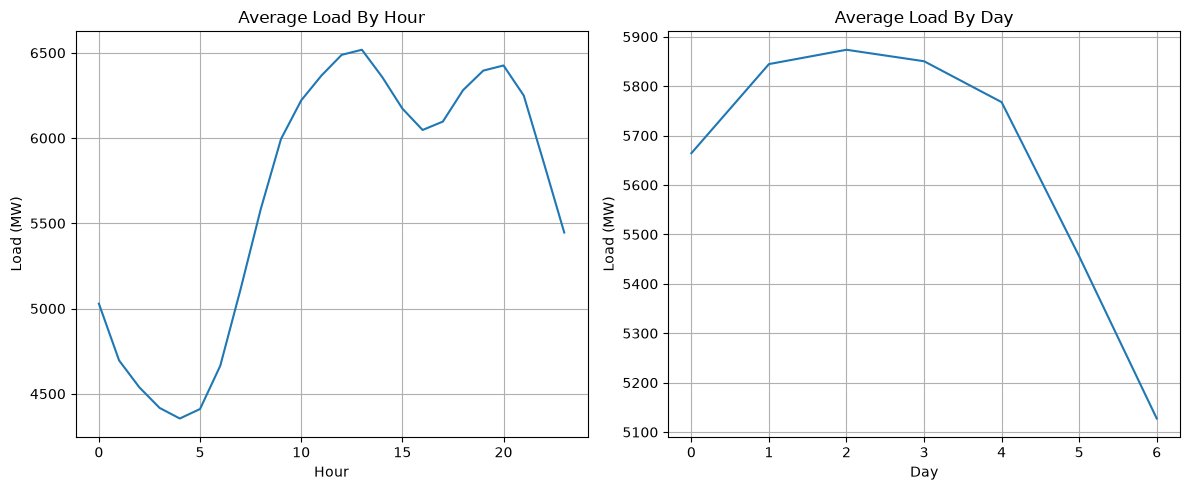

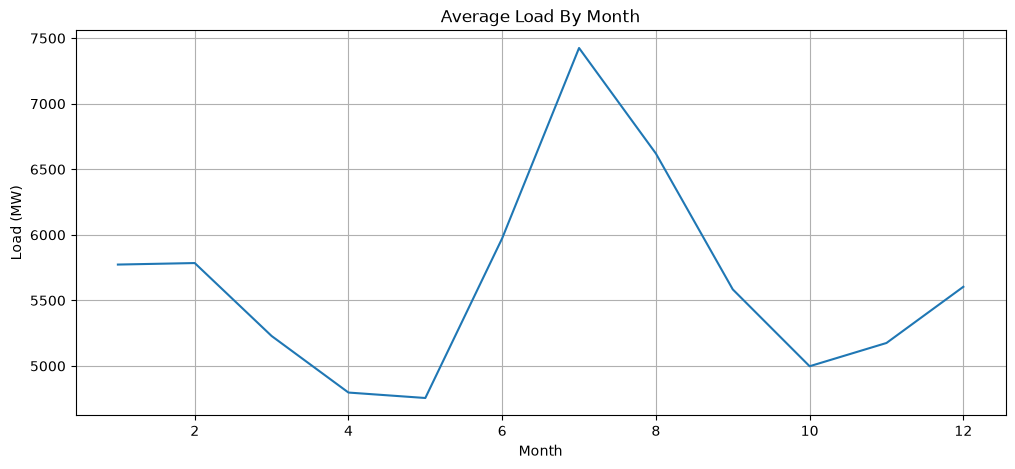

In [ ]:
##The code below is for feature engineering. It creates new features based on the existing data, such as lagged load values, rolling averages, and time-based features like hour of the day, day of the week, month, and weekend indicator. These features can be used for predictive modeling and analysis.

data["Hour"]=data.index.hour
data["Day Of The Week"]=data.index.dayofweek
data["Month"]=data.index.month
data["Weekend"]=data["Day Of The Week"].isin([5,6])
print(data[["temp_athens","Hour","Day Of The Week","Month","Weekend"]].head(48))


load_by_hour=data.groupby("Hour")["Actual Load"].mean()
load_by_day=data.groupby("Day Of The Week")["Actual Load"].mean()
load_by_month=data.groupby("Month")["Actual Load"].mean()
load_by_weekend=data.groupby("Weekend")["Actual Load"].mean()

print(f"Average Load By Hour: {load_by_hour}")
print(f"Average Load By Day: {load_by_day}")
print(f"Average Load By Month: {load_by_month}")
print(f"Average Load By Weekend: {load_by_weekend}")


#More visualizations to understand the patterns in electricity load based on different time features.

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
load_by_hour.plot(
    title="Average Load By Hour",
    xlabel="Hour",
    ylabel="Load (MW)"
)
plt.grid(True)

plt.subplot(1,2,2)
load_by_day.plot(
    title="Average Load By Day",
    xlabel="Day",
    ylabel="Load (MW)"
  
)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
load_by_month.plot(
    title="Average Load By Month",
    xlabel="Month",
    ylabel="Load (MW)"

)
plt.grid(True)
plt.show()

In [ ]:
### NEW FEATURES for the prophet_v2 

data["load lag 24"]=data["Actual Load"].shift(24)
data["load lag 168"]=data["Actual Load"].shift(168)

data["temp squared"]=data["temp_athens"]**2


data["temp 7 days rolling"]=data["temp_athens"].rolling(window=168).mean()

###DROPPING NAN VALUES 
data=data.dropna()

print(data.head(200))

                           Actual Load  temp_athens  Hour  Day Of The Week  \
2023-01-08 00:00:00+02:00       4693.0         7.05     0                6   
2023-01-08 01:00:00+02:00       4323.0         6.65     1                6   
2023-01-08 02:00:00+02:00       4193.0         5.90     2                6   
2023-01-08 03:00:00+02:00       4017.0         5.65     3                6   
2023-01-08 04:00:00+02:00       3919.0         5.55     4                6   
...                                ...          ...   ...              ...   
2023-01-16 03:00:00+02:00       4036.0         6.50     3                0   
2023-01-16 04:00:00+02:00       3972.0         6.30     4                0   
2023-01-16 05:00:00+02:00       4138.0         6.25     5                0   
2023-01-16 06:00:00+02:00       4755.0         5.90     6                0   
2023-01-16 07:00:00+02:00       5630.0         5.70     7                0   

                           Month  Weekend  load lag 24  load la

                           Actual Load  temp_athens  Hour  Day Of The Week  \
2025-01-01 01:00:00+02:00      4545.00     6.700000     1                2   
2025-01-01 02:00:00+02:00      4376.00     5.950000     2                2   
2025-01-01 03:00:00+02:00      4150.00     7.450000     3                2   
2025-01-01 04:00:00+02:00      3984.00     7.350000     4                2   
2025-01-01 05:00:00+02:00      3965.00     7.300000     5                2   
...                                ...          ...   ...              ...   
2026-08-06 19:00:00+03:00      8447.75    33.450001    19                3   
2026-08-06 20:00:00+03:00      8195.75    32.349998    20                3   
2026-08-06 21:00:00+03:00      8098.50    31.600000    21                3   
2026-08-06 22:00:00+03:00      7702.00    30.600000    22                3   
2026-08-06 23:00:00+03:00      7297.75    29.700001    23                3   

                           Month  Weekend  load lag 24  load la

In [ ]:
#Baseline Forecasting and Evaluation

import numpy as np

train=data[data.index.year < 2025]
test=data[data.index.year >= 2025]

print(f"Train Shape: {train.shape} (2023-2024)")
print(f"Test Shape: {test.shape} (2025-2026)")
print(f"Train dates: {train.index[0]} to {train.index[-1]}")
print(f"Test dates: {test.index[0]} to {test.index[-1]}")


test["Baseline Forecast"]=test["Actual Load"].shift(168)
baseline_mape=np.mean(np.abs((test["Actual Load"]-test["Baseline Forecast"])/test["Actual Load"]))*100

print(f"Baseline MAPE: {baseline_mape:.2f}%")
print(f"\nFirst 24 Hours Of The Test Predicitons")
print(test[["Actual Load","Baseline Forecast"]].head(300))



Train Shape: (17374, 10) (2023-2024)
Test Shape: (13990, 10) (2025-2026)
Train dates: 2023-01-08 00:00:00+02:00 to 2024-12-31 23:00:00+02:00
Test dates: 2025-01-01 01:00:00+02:00 to 2026-08-06 23:00:00+03:00
Baseline MAPE: 7.40%

First 24 Hours Of The Test Predicitons
                           Actual Load  Baseline Forecast
2025-01-01 01:00:00+02:00       4545.0                NaN
2025-01-01 02:00:00+02:00       4376.0                NaN
2025-01-01 03:00:00+02:00       4150.0                NaN
2025-01-01 04:00:00+02:00       3984.0                NaN
2025-01-01 05:00:00+02:00       3965.0                NaN
...                                ...                ...
2025-01-13 08:00:00+02:00       6483.0             4583.0
2025-01-13 09:00:00+02:00       7215.0             4882.0
2025-01-13 10:00:00+02:00       7575.0             5085.0
2025-01-13 11:00:00+02:00       7749.0             5314.0
2025-01-13 12:00:00+02:00       7889.0             5487.0

[300 rows x 2 columns]


In [ ]:
#ProphetForecast
from prophet import Prophet

train_prophet=train[["Actual Load"]].reset_index()
train_prophet.columns=["ds","y"] #ds=date y=load
train_prophet["ds"]=train_prophet["ds"].dt.tz_localize(None)
train_prophet["temp_athens"]=train["temp_athens"].values

#print(f"Train data for Prophet:")
#print(train_prophet.head())

model=Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)
model.add_regressor("temp_athens")
model.fit(train_prophet)

future=test[["Actual Load"]].reset_index()
future = future.rename(columns={'index': 'ds'})
future["ds"]=future["ds"].dt.tz_localize(None)
future=future[["ds"]]
future["temp_athens"]=test["temp_athens"].values


forecast=model.predict(future)
#print(forecast[["ds","yhat"]].head(24))

#print(f"Train data shape: {train_prophet.shape}")
#print(f"Forecast shape: {forecast.shape}")
#print(f"Test data shape: {test.shape}")

test["prophet forecast"]=forecast["yhat"].values
baseline_mape=np.mean(np.abs((test["Actual Load"]-test["Baseline Forecast"])/test["Actual Load"]))*100
prophet_mape=np.mean(np.abs((test["Actual Load"]-test["prophet forecast"])/test["Actual Load"]))*100

print(f"Baseline MAPE: {baseline_mape:.2f}%")
print(f"Prophet MAPE: {prophet_mape:.2f}%")

if prophet_mape < baseline_mape:
  improvement=baseline_mape - prophet_mape
  print(f"\n Prophet is Better By: {improvement:.2f}%")
else:
  print(f"\n Baseline Is Better By: {baseline_mape - prophet_mape:.2f}%")

  #With only these features the baseline forecast beats prophet forecast
  #so i will try to add some more features to see if the prophet can beat the baseline


02:40:04 - cmdstanpy - INFO - Chain [1] start processing
02:40:18 - cmdstanpy - INFO - Chain [1] done processing


Baseline MAPE: 7.40%
Prophet MAPE: 8.57%

 Baseline Is Better By: -1.18%


In [ ]:
###PROPHET WITH MORE FEATURES

from prophet import Prophet

train_prophet=train[["Actual Load"]].reset_index()
train_prophet.columns=["ds","y"]
train_prophet["ds"]=train_prophet["ds"].dt.tz_localize(None)


train_prophet["temp_athens"]=train["temp_athens"].values
train_prophet["load lag 24"]=train["load lag 24"].values
train_prophet["load lag 168"]=train["load lag 168"].values  
train_prophet["temp 7 days rolling"]=train["temp 7 days rolling"].values
train_prophet["temp squared"]=train["temp squared"].values

print(f"Train data for Prophet with more features:")
model_v2=Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)

for col in ["temp_athens","load lag 24","load lag 168","temp 7 days rolling","temp squared"]:
    model_v2.add_regressor(col)


model_v2.fit(train_prophet)

future=test[["Actual Load"]].reset_index()
future.columns=["ds","ignore"]
future["ds"]=future["ds"].dt.tz_localize(None)
future[['temp_athens', 'load lag 24', 'load lag 168', 'temp squared', 'temp 7 days rolling']] = \
    test[['temp_athens', 'load lag 24', 'load lag 168', 'temp squared', 'temp 7 days rolling']].values

forecast_v2=model_v2.predict(future)
prophet_v2_mape=np.mean(np.abs((test["Actual Load"]-forecast_v2["yhat"].values)/test["Actual Load"]))*100

if prophet_v2_mape < baseline_mape:
  improvement=baseline_mape - prophet_v2_mape
  print(f"\n Prophet is Better By: {improvement:.2f}%")
else:
  print(f"\n Baseline Is Better By: {baseline_mape - prophet_v2_mape:.2f}%")
    

Train data for Prophet with more features:


02:40:21 - cmdstanpy - INFO - Chain [1] start processing
02:40:25 - cmdstanpy - INFO - Chain [1] done processing



 Baseline Is Better By: -0.47%


In [ ]:
#Linear Regression Model
from sklearn.linear_model import LinearRegression

features = ['temp_athens', 'load lag 24', 'load lag 168', 'temp squared', 'temp 7 days rolling']

X_train = train[features].values
y_train = train["Actual Load"].values

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

for feat, coef in zip(features, lr_model.coef_):
    print(f"  {feat}: {coef:.2f}")

X_test = test[features].values
lr_forecast = lr_model.predict(X_test)


lr_mape = np.mean(np.abs((test['Actual Load'].values - lr_forecast) / test['Actual Load'].values)) * 100

print(f"\nLinear Regression MAPE: {lr_mape:.2f}%")

  temp_athens: -66.12
  load lag 24: 0.59
  load lag 168: 0.30
  temp squared: 2.01
  temp 7 days rolling: -5.35

Linear Regression MAPE: 4.95%


In [45]:
#Actual Results and Comparison

print("=" * 60)
print("FINAL MODEL COMPARISON - ALL MODELS")
print("=" * 60)
print(f"1. Linear Regression (with features):    {lr_mape:.2f}%  ✓ WINNER")
print(f"2. Baseline (same day last week):        {baseline_mape:.2f}%")
print(f"3. Prophet v2 (with features):           {prophet_v2_mape:.2f}%")
print("=" * 60)
print(f"\nLinear Regression wins by {baseline_mape - lr_mape:.2f}% over baseline")
print(f"and by {prophet_v2_mape - lr_mape:.2f}% over Prophet v2")

FINAL MODEL COMPARISON - ALL MODELS
1. Linear Regression (with features):    4.95%  ✓ WINNER
2. Baseline (same day last week):        7.40%
3. Prophet v2 (with features):           7.87%

Linear Regression wins by 2.45% over baseline
and by 2.92% over Prophet v2


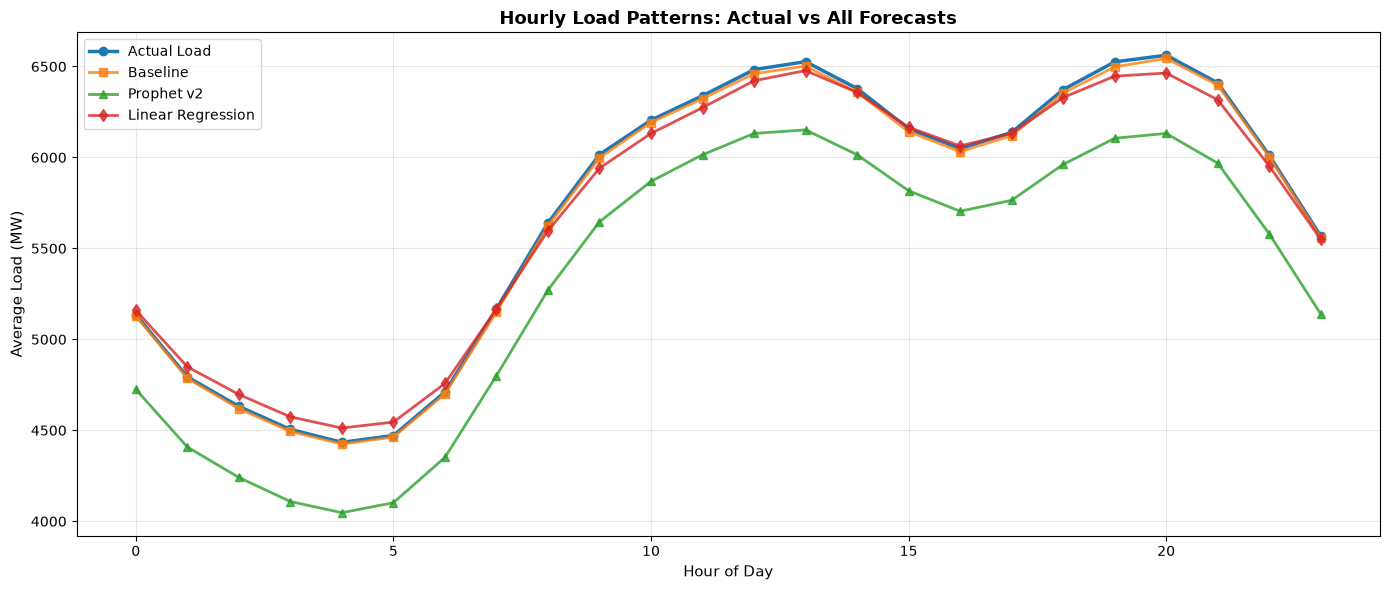

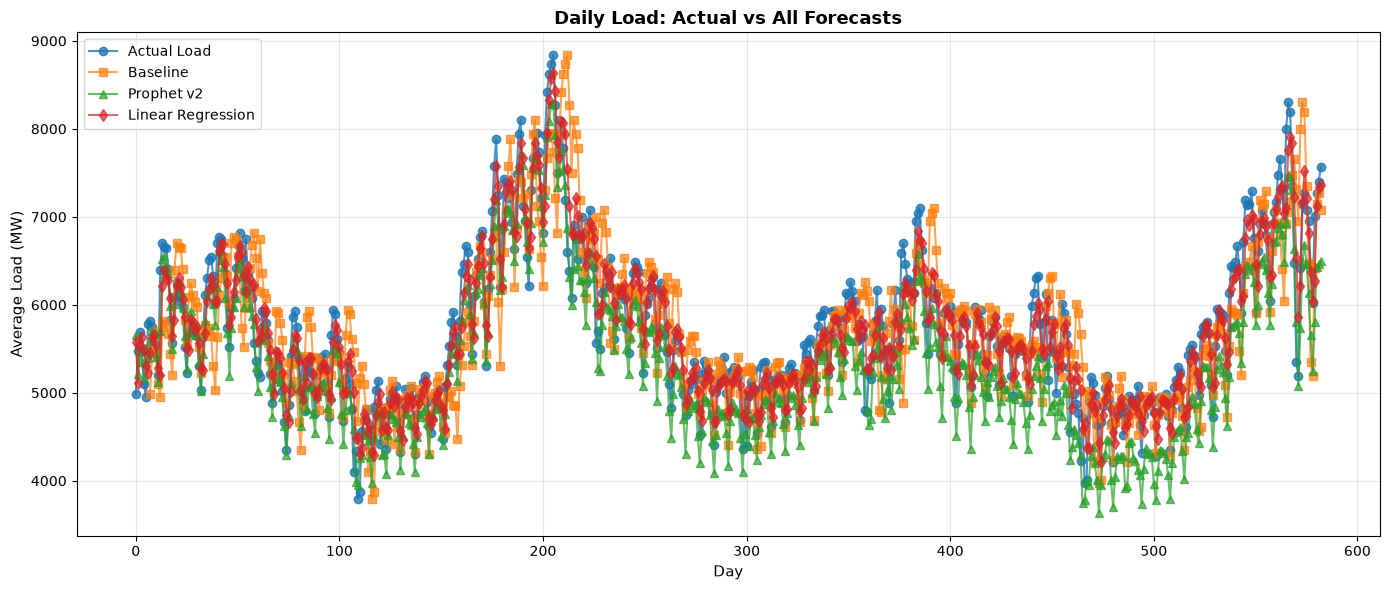

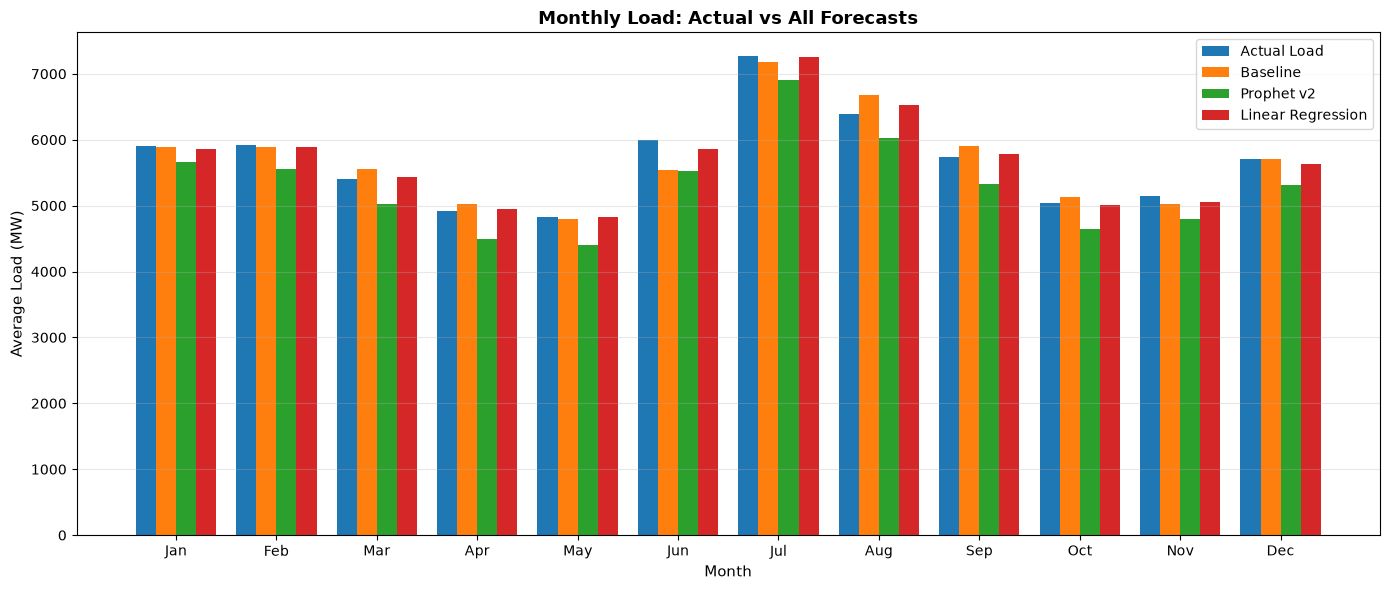

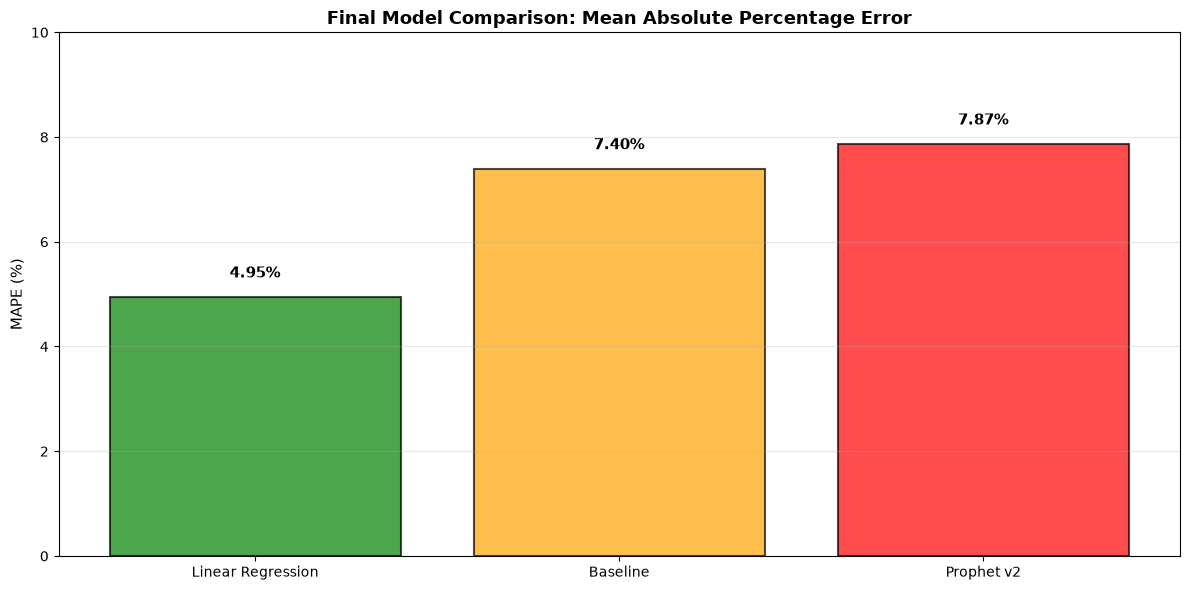

In [ ]:
#Comparing the forecasts from Prophet v2 and Linear Regression with the actual load and baseline forecast using visualizations.
import matplotlib.pyplot as plt
test['prophet_v2_forecast'] = forecast_v2['yhat'].values
test['lr_forecast'] = lr_forecast


hourly_actual = test.groupby('Hour')['Actual Load'].mean()
hourly_baseline = test.groupby('Hour')['Baseline Forecast'].mean()
hourly_prophet_v2 = test.groupby('Hour')['prophet_v2_forecast'].mean()
hourly_lr = test.groupby('Hour')['lr_forecast'].mean()

plt.figure(figsize=(14, 6))
plt.plot(hourly_actual.index, hourly_actual.values, marker='o', label='Actual Load', linewidth=2.5)
plt.plot(hourly_baseline.index, hourly_baseline.values, marker='s', label='Baseline', linewidth=2, alpha=0.8)
plt.plot(hourly_prophet_v2.index, hourly_prophet_v2.values, marker='^', label='Prophet v2', linewidth=2, alpha=0.8)
plt.plot(hourly_lr.index, hourly_lr.values, marker='d', label='Linear Regression', linewidth=2, alpha=0.8)
plt.xlabel('Hour of Day', fontsize=11)
plt.ylabel('Average Load (MW)', fontsize=11)
plt.title('Hourly Load Patterns: Actual vs All Forecasts', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

daily_actual = test.groupby(test.index.date)['Actual Load'].mean()
daily_baseline = test.groupby(test.index.date)['Baseline Forecast'].mean()
daily_prophet_v2 = test.groupby(test.index.date)['prophet_v2_forecast'].mean()
daily_lr = test.groupby(test.index.date)['lr_forecast'].mean()


plt.figure(figsize=(14, 6))
plt.plot(range(len(daily_actual)), daily_actual.values, marker='o', label='Actual Load', linewidth=1.5, alpha=0.8)
plt.plot(range(len(daily_baseline)), daily_baseline.values, marker='s', label='Baseline', linewidth=1.5, alpha=0.7)
plt.plot(range(len(daily_prophet_v2)), daily_prophet_v2.values, marker='^', label='Prophet v2', linewidth=1.5, alpha=0.7)
plt.plot(range(len(daily_lr)), daily_lr.values, marker='d', label='Linear Regression', linewidth=1.5, alpha=0.7)
plt.xlabel('Day', fontsize=11)
plt.ylabel('Average Load (MW)', fontsize=11)
plt.title('Daily Load: Actual vs All Forecasts', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


monthly_actual = test.groupby('Month')['Actual Load'].mean()
monthly_baseline = test.groupby('Month')['Baseline Forecast'].mean()
monthly_prophet_v2 = test.groupby('Month')['prophet_v2_forecast'].mean()
monthly_lr = test.groupby('Month')['lr_forecast'].mean()

plt.figure(figsize=(14, 6))
x = range(1, 13)
width = 0.2

plt.bar([i - 1.5*width for i in x], monthly_actual.values, width, label='Actual Load')
plt.bar([i - 0.5*width for i in x], monthly_baseline.values, width, label='Baseline')
plt.bar([i + 0.5*width for i in x], monthly_prophet_v2.values, width, label='Prophet v2')
plt.bar([i + 1.5*width for i in x], monthly_lr.values, width, label='Linear Regression')

plt.xlabel('Month', fontsize=11)
plt.ylabel('Average Load (MW)', fontsize=11)
plt.title('Monthly Load: Actual vs All Forecasts', fontsize=13, fontweight='bold')
plt.xticks(x, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
models = ['Linear Regression', 'Baseline', 'Prophet v2']
mape_values = [lr_mape, baseline_mape, prophet_v2_mape]
colors = ['green', 'orange', 'red']

bars = plt.bar(models, mape_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.ylabel('MAPE (%)', fontsize=11)
plt.title('Final Model Comparison: Mean Absolute Percentage Error', fontsize=13, fontweight='bold')
plt.ylim([0, 10])

for i, (bar, v) in enumerate(zip(bars, mape_values)):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.2f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()







In [ ]:
##ERROR ANALYSIS trying to find out where the baseline actually fails


test["baseline_error"]=np.abs((test["Actual Load"]-test["Baseline Forecast"])/test["Actual Load"])*100


error_by_hour=test.groupby("Hour")["baseline_error"].agg(["mean","max","std"])
print("MAPE by Hour of Day:")
print(error_by_hour.round(2))
print()

error_by_month=test.groupby("Month")["baseline_error"].agg(["mean","max","std"])
print("MAPE by Month:")
print(error_by_month.round(2))
print()

error_by_day=test.groupby("Day Of The Week")["baseline_error"].agg(["mean","max","std"])
print("MAPE by Day of the Week (0=Monday, 6=Sunday):")
print(error_by_day.round(2))

MAPE by Hout of Day:
      mean    max   std
Hour                   
0     6.42  39.49  5.89
1     6.22  37.55  5.71
2     6.04  35.64  5.60
3     5.91  34.95  5.46
4     5.79  33.07  5.30
5     5.72  30.79  5.29
6     6.16  36.42  5.93
7     6.83  50.17  7.25
8     7.09  55.59  7.68
9     7.29  51.40  7.52
10    7.59  46.54  7.18
11    8.01  51.38  7.28
12    8.41  53.58  7.51
13    8.83  51.89  7.67
14    9.43  50.67  8.27
15    9.85  49.52  8.53
16    9.58  52.90  8.45
17    9.07  49.83  8.10
18    8.21  44.95  7.39
19    7.58  40.59  6.91
20    7.18  39.77  6.52
21    6.86  37.64  6.20
22    6.81  34.74  5.99
23    6.67  37.94  5.93

MAPE by Month:
        mean    max   std
Month                    
1       8.84  38.02  6.54
2       6.19  31.82  5.63
3       8.43  50.67  7.01
4      10.25  53.58  9.72
5       3.76  37.66  3.88
6       7.85  32.93  5.39
7       8.89  52.90  7.46
8      10.18  41.12  8.91
9       5.89  24.90  5.04
10      4.92  36.18  5.02
11      3.97  26.54  3.68
1

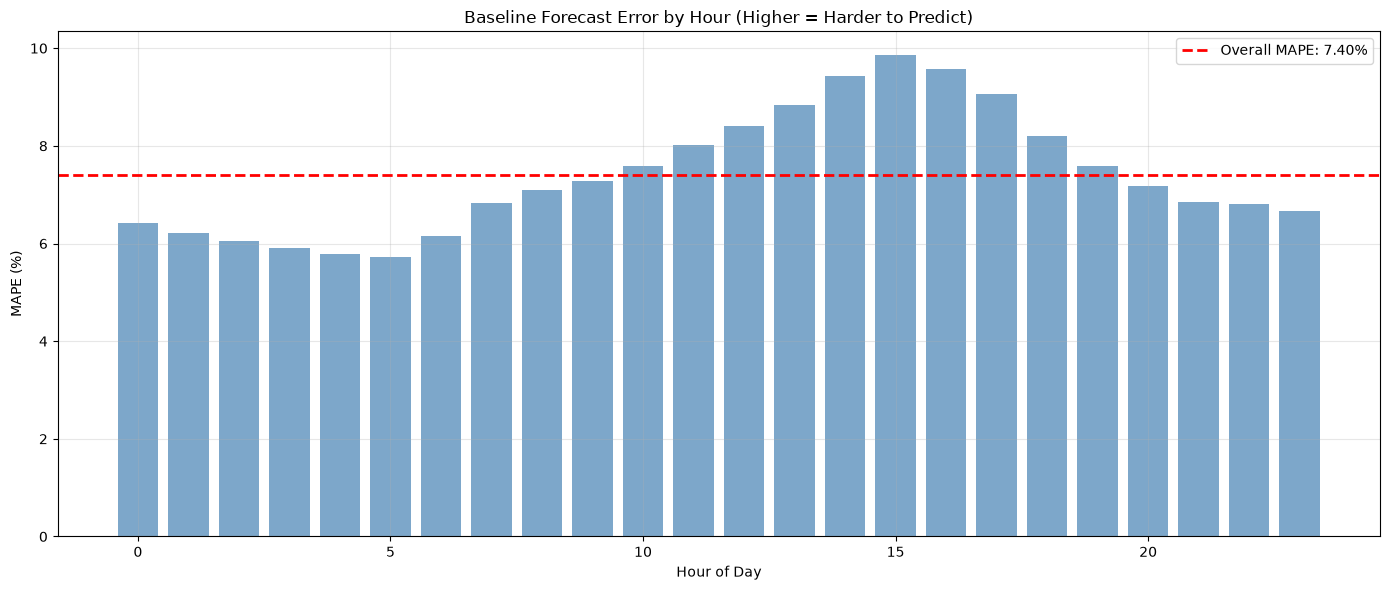

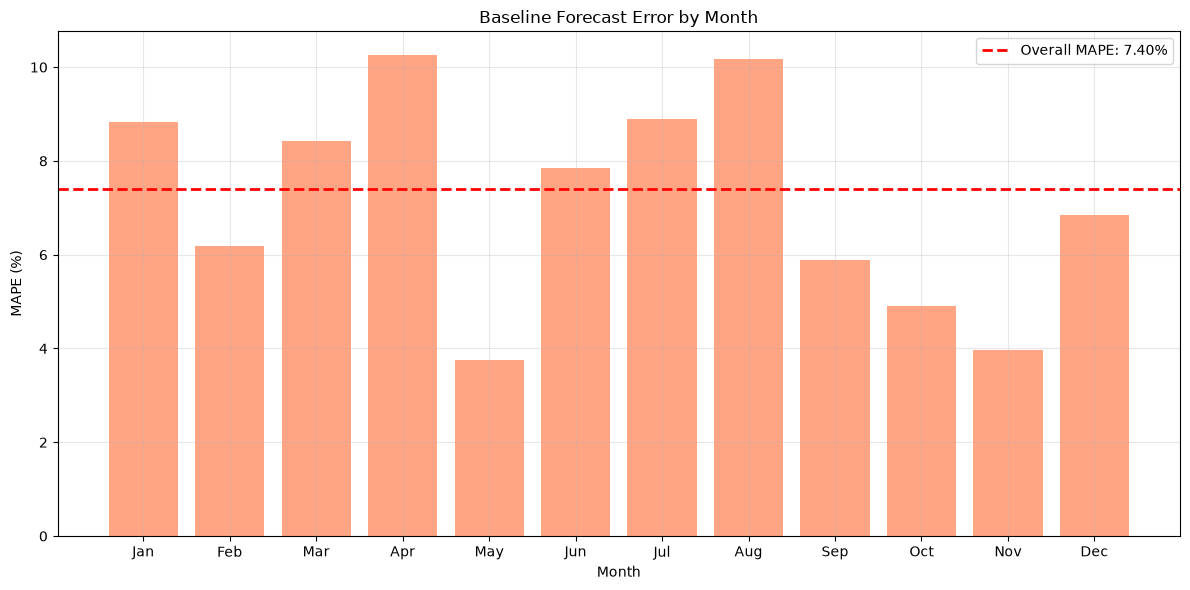

In [40]:
##VISUALIZING THE ERROR ANALYSIS

error_by_hour_mean = test.groupby('Hour')['baseline_error'].mean()

plt.figure(figsize=(14, 6))
plt.bar(error_by_hour_mean.index, error_by_hour_mean.values, color='steelblue', alpha=0.7)
plt.axhline(y=baseline_mape, color='red', linestyle='--', linewidth=2, label=f'Overall MAPE: {baseline_mape:.2f}%')
plt.xlabel('Hour of Day')
plt.ylabel('MAPE (%)')
plt.title('Baseline Forecast Error by Hour (Higher = Harder to Predict)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



error_by_month_mean = test.groupby('Month')['baseline_error'].mean()


plt.figure(figsize=(12, 6))
plt.bar(error_by_month_mean.index, error_by_month_mean.values, color='coral', alpha=0.7)
plt.axhline(y=baseline_mape, color='red', linestyle='--', linewidth=2, label=f'Overall MAPE: {baseline_mape:.2f}%')
plt.xlabel('Month')
plt.ylabel('MAPE (%)')
plt.title('Baseline Forecast Error by Month')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




